In [332]:
from tokenize import cookie_re

import numpy as np
import pandas as pd

# pd.Series

Создание обычного массива pd.Series

In [14]:
some_list = [1, 3, 5, np.nan, 6, 8]
ser_1 = pd.Series(some_list)
ser_1

0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
dtype: float64

В качестве индексов может выступать определённый массив

In [15]:
ind = ["1st day", "2nd day", "3td day", "4th day", "5th day", "6th day"]
ser_2 = pd.Series(some_list, index=ind)
ser_2

1st day    1.0
2nd day    3.0
3td day    5.0
4th day    NaN
5th day    6.0
6th day    8.0
dtype: float64

Данным pd.Series можно дать имя

In [19]:
ser_3 = pd.Series(some_list, index=ind, name="Temperature")
ser_3

1st day    1.0
2nd day    3.0
3td day    5.0
4th day    NaN
5th day    6.0
6th day    8.0
Name: Temperature, dtype: float64

## Индексирование

In [60]:
print(ser_3.loc["1st day"])
print("---------------")
print(ser_3.loc[["1st day"]])
print("---------------")
print(ser_3.iloc[[0]])
print("---------------")
print(ser_3[1:3])
print("---------------")
print(ser_3.iloc[::-1])

1.0
---------------
1st day    1.0
Name: Temperature, dtype: float64
---------------
1st day    1.0
Name: Temperature, dtype: float64
---------------
2nd day    3.0
3td day    5.0
Name: Temperature, dtype: float64
---------------
6th day    8.0
5th day    6.0
4th day    NaN
3td day    5.0
2nd day    3.0
1st day    1.0
Name: Temperature, dtype: float64


Индексирование по условию

In [65]:
date_range = pd.date_range("20260101", periods=10)
ser_4 = pd.Series(np.random.rand(10), index=date_range)
ser_4

2026-01-01    0.703621
2026-01-02    0.676541
2026-01-03    0.164276
2026-01-04    0.338657
2026-01-05    0.177283
2026-01-06    0.101499
2026-01-07    0.961806
2026-01-08    0.018680
2026-01-09    0.954786
2026-01-10    0.874576
Freq: D, dtype: float64

In [68]:
ser_4 > 0.5

2026-01-01     True
2026-01-02     True
2026-01-03    False
2026-01-04    False
2026-01-05    False
2026-01-06    False
2026-01-07     True
2026-01-08    False
2026-01-09     True
2026-01-10     True
Freq: D, dtype: bool

In [69]:
ser_4[ser_4 > 0.5]

2026-01-01    0.703621
2026-01-02    0.676541
2026-01-07    0.961806
2026-01-09    0.954786
2026-01-10    0.874576
dtype: float64

In [73]:
ser_4[(ser_4 > 0.6) | (ser_4 < 0.2)]

2026-01-01    0.703621
2026-01-02    0.676541
2026-01-03    0.164276
2026-01-05    0.177283
2026-01-06    0.101499
2026-01-07    0.961806
2026-01-08    0.018680
2026-01-09    0.954786
2026-01-10    0.874576
dtype: float64

In [74]:
ser_4[(ser_4 > 0.6) & (ser_4 < 0.2)]

Series([], Freq: D, dtype: float64)

## Сортировки (не меняют исходных массив)

In [75]:
ser_4.sort_index()

2026-01-01    0.703621
2026-01-02    0.676541
2026-01-03    0.164276
2026-01-04    0.338657
2026-01-05    0.177283
2026-01-06    0.101499
2026-01-07    0.961806
2026-01-08    0.018680
2026-01-09    0.954786
2026-01-10    0.874576
Freq: D, dtype: float64

In [76]:
ser_4.sort_values()

2026-01-08    0.018680
2026-01-06    0.101499
2026-01-03    0.164276
2026-01-05    0.177283
2026-01-04    0.338657
2026-01-02    0.676541
2026-01-01    0.703621
2026-01-10    0.874576
2026-01-09    0.954786
2026-01-07    0.961806
dtype: float64

## Операции с Series

In [77]:
ser_4 + 100

2026-01-01    100.703621
2026-01-02    100.676541
2026-01-03    100.164276
2026-01-04    100.338657
2026-01-05    100.177283
2026-01-06    100.101499
2026-01-07    100.961806
2026-01-08    100.018680
2026-01-09    100.954786
2026-01-10    100.874576
Freq: D, dtype: float64

In [79]:
np.exp(ser_4)

2026-01-01    2.021058
2026-01-02    1.967062
2026-01-03    1.178540
2026-01-04    1.403062
2026-01-05    1.193968
2026-01-06    1.106829
2026-01-07    2.616417
2026-01-08    1.018855
2026-01-09    2.598116
2026-01-10    2.397859
Freq: D, dtype: float64

In [83]:
term_1 = pd.Series(np.random.randint(0, 5, 5))
term_2 = pd.Series(np.random.randint(0, 5, 6))
term_1 + term_2

0    4.0
1    6.0
2    0.0
3    3.0
4    4.0
5    NaN
dtype: float64

In [84]:
term_1.shape

(5,)

# pd.DataFrame

Создание и основные объекты

In [504]:
some_dict = {"one": pd.Series([1, 2, 3], index=['a', 'b', 'c']),
             "two": pd.Series([4, 5, 6, 7], index=['a', 'b', 'c', 'd']),
             "three": pd.Series([8, 9, 10, 11], index=['a', 'b', 'c', 'd'])}
df = pd.DataFrame(some_dict)
print(df)

   one  two  three
a  1.0    4      8
b  2.0    5      9
c  3.0    6     10
d  NaN    7     11


In [88]:
some_dict = {"one": pd.Series([1, 2, 3], index=['a', 'b', 'c']),
             "two": pd.Series([99, 4, 5, 6], index=['c', 'd', 'e', 'f']),
             "three": pd.Series([99, 8, 9, 10], index=['c', 'd', 'e', 'f'])}
df = pd.DataFrame(some_dict)
df

,one,two,three
a,1.0,NaN,NaN
b,2.0,NaN,NaN
c,3.0,99.0,99.0
d,NaN,4.0,8.0
e,NaN,5.0,9.0
f,NaN,6.0,10.0


Альтернатива - создание из списка списков с аргументов columns

In [505]:
some_array = [[1, 2, 3],
              [4, 5, 6],
              [np.nan, 8, 9],
              [10, 11]]
df = pd.DataFrame(some_array, index=['a', 'b', 'c', 'd'], columns=['one', 'two', 'three'])
print(df)

    one  two  three
a   1.0    2    3.0
b   4.0    5    6.0
c   NaN    8    9.0
d  10.0   11    NaN


In [91]:
print(df.values)

[[ 1.  2.  3.]
 [ 4.  5.  6.]
 [nan  8.  9.]
 [10. 11. nan]]


In [95]:
print(df.columns)

Index(['one', 'two', 'three'], dtype='str')


Атрибуты _index_ и _columns_ можно менять

In [98]:
df.columns = ["first", "second", "third"]
df.index = [1, 2, 3, 4]
df

,first,second,third
1,1.0,2,3.0
2,4.0,5,6.0
3,NaN,8,9.0
4,10.0,11,NaN


## Индексирование

По колонкам

In [104]:
first_column = df["first"]
first_column

1     1.0
2     4.0
3     NaN
4    10.0
Name: first, dtype: float64

In [105]:
df.first

1     1.0
2     4.0
3     NaN
4    10.0
Name: first, dtype: float64

In [106]:
subset_df = df[["first", "second"]]
subset_df

,first,second
1,1.0,2
2,4.0,5
3,NaN,8
4,10.0,11


In [107]:
# DataFrame из одного столбца
one_column_df = df[["third"]]
one_column_df

,third
1,3.0
2,6.0
3,9.0
4,NaN


По строкам

In [108]:
df[:1]

,first,second,third
1,1.0,2,3.0


In [109]:
df[1:4]

,first,second,third
2,4.0,5,6.0
3,NaN,8,9.0
4,10.0,11,NaN


Универсальное индексирование: _.loc_ и _.iloc_

In [110]:
#  По номерам индексов
df.iloc[1:3, :2]

,first,second
2,4.0,5
3,NaN,8


In [111]:
#  По названию индексов
df.loc[1:3, ["first", "second"]]

,first,second
1,1.0,2
2,4.0,5
3,NaN,8


**ATTENTION: Когда мы обращаемся по названию индекса, правая граница називает включаться!**

Лучше использовать по умолчанию либо только *loc*, либо только *iloc*. А лучше вообще всегда только *iloc*, чтобы не запутаться.

## Модификация датасета, создание новых колонок

Создание новой колонки

In [118]:
new_column = [5, 2, 1, 4]
df["new_column"] = new_column
df

,first,second,third,new_column
1,1.0,2,3.0,5
2,4.0,5,6.0,2
3,NaN,8,9.0,1
4,10.0,11,NaN,4


Модификация колонки

In [122]:
df["first"] = df["first"] * 10
df

,first,second,third,new_column
1,10.0,2,3.0,5
2,40.0,5,6.0,2
3,NaN,8,9.0,1
4,100.0,11,NaN,4


# Реальный датасет

Работа с датасетом **Титаник**. Файлы необходимо скачать [с Kaggle](https://www.kaggle.com/c/titanic/data?select=train.csv).

## Чтение из файла

In [476]:
titanic_passengers = pd.read_csv("resources/train.csv", index_col="PassengerId")
print("Total passengers is {}".format(len(titanic_passengers)))
titanic_passengers = titanic_passengers.drop("Survived", axis=1)
titanic_passengers.head(10)

Total passengers is 891


,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
8,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
9,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S


## Разная информация о датасете

Можно узнать размер таблицы, информацию о значениях таблицы, различные статистики по значениям.

In [282]:
titanic_passengers.shape

(891, 10)

In [283]:
titanic_passengers.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Name      891 non-null    str    
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Ticket    891 non-null    str    
 7   Fare      891 non-null    float64
 8   Cabin     204 non-null    str    
 9   Embarked  889 non-null    str    
dtypes: float64(2), int64(3), str(5)
memory usage: 69.7 KB


In [284]:
titanic_passengers.describe()

,Pclass,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,2.000000,20.125000,0.000000,0.000000,7.910400
50%,3.000000,28.000000,0.000000,0.000000,14.454200
75%,3.000000,38.000000,1.000000,0.000000,31.000000
max,3.000000,80.000000,8.000000,6.000000,512.329200


**Задание 1**

- Опишите данный датасет: какое распределение женщин/мужчин в нём?
- Сколько пассажиров ехало в каждом классе?
- Какой средний/минимальный/максимальный возраст пассажиров?

In [285]:
#  Распределение мужчин/женщин

#  Моё решение
print("Total man: {mans} \nTotal woman: {womans}".format(
    mans=len(titanic_passengers[titanic_passengers["Sex"] == "male"]),
    womans=len(titanic_passengers[titanic_passengers["Sex"] == "female"])
))

#  Оптимальное решение
print("-------------")
print(titanic_passengers["Sex"].value_counts())


Total man: 577 
Total woman: 314
-------------
Sex
male      577
female    314
Name: count, dtype: int64


In [286]:
#  Количество пассажиров в каждом классе
print("Total passengers in 1st class: {first} \nTotal passengers in 2nd class: {second} \nTotal passengers in 3rd class: {third}".format(
    first=len(titanic_passengers[titanic_passengers["Pclass"] == 1]),
    second=len(titanic_passengers[titanic_passengers["Pclass"] == 2]),
    third=len(titanic_passengers[titanic_passengers["Pclass"] == 3])
))

#  Оптимальное решение
print("--------------")
print(titanic_passengers["Pclass"].value_counts().sort_index())

Total passengers in 1st class: 216 
Total passengers in 2nd class: 184 
Total passengers in 3rd class: 491
--------------
Pclass
1    216
2    184
3    491
Name: count, dtype: int64


In [287]:
#  Средний/минимальный/максимальный возраст пассажиров

print("Average age of passengers: {avg} \nMinimum age of passengers: {min} \nMaximum age of passengers: {max}".format(
    avg=titanic_passengers["Age"].mean(),
    min=titanic_passengers["Age"].min(),
    max=titanic_passengers["Age"].max()
))

Average age of passengers: 29.69911764705882 
Minimum age of passengers: 0.42 
Maximum age of passengers: 80.0


**Задание 2**

Сгруппируйте записи по классам пассажиров, в каждой группе посчитайте средний возраст. Используйте метод `pandas.DataFrame.groupby`.

In [288]:
print(titanic_passengers.groupby(["Pclass"])["Age"].mean())

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64


## Слияние таблиц

Слияние по индексу `pd.join`

In [477]:
survived_passengers = pd.read_csv("resources/titanic_survived.csv")
survived_passengers.head()

,Survived
0,1
1,1
2,1
3,1
4,0


**Задание 3**

Слейте два датасета по колонке индекса.

In [478]:
survived_passengers.index = np.arange(1, 892)
survived_passengers.index.name = "PassengerId"
survived_passengers.head()

,Survived
PassengerId,
1,1
2,1
3,1
4,1
5,0


In [493]:
titanic_passengers = titanic_passengers.join(other=survived_passengers, on="PassengerId")
titanic_passengers

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
PassengerId,,,,,,,,,,,
1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...
887,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0
888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1
889,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,1


**Задание 4**

- Сколько всего выживших пассажиров?
- Выживших пассажиров по каждому из полов?
- Пастройте матрицу корреляций факта выживания, пола и возраста.

In [481]:
print("Total survivors: {total} \nTotal man survivors: {man} \nTotal woman survivors {woman}".format(
    total=int(titanic_passengers["Survived"].value_counts()[1]),
    man=int(titanic_passengers.groupby("Sex")["Survived"].value_counts()[3:4].values[0]),
    woman=int(titanic_passengers.groupby("Sex")["Survived"].value_counts()[0:1].values[0])
))

#  Оптимальное решение
print("-------------")
print(titanic_passengers["Survived"].sum())
print(titanic_passengers.groupby("Sex")["Survived"].sum())

Total survivors: 439 
Total man survivors: 278 
Total woman survivors 161
-------------
439
Sex
female    161
male      278
Name: Survived, dtype: int64


In [500]:
corr_data = titanic_passengers[["Sex", "Age", "Survived"]]
corr_data["Sex"] = (corr_data["Sex"] == "male").astype(int)
corr_data.corr()

,Sex,Age,Survived
Sex,1.000000,0.093254,-0.029561
Age,0.093254,1.000000,-0.027876
Survived,-0.029561,-0.027876,1.000000


In [501]:
import seaborn as sns

<Axes: >

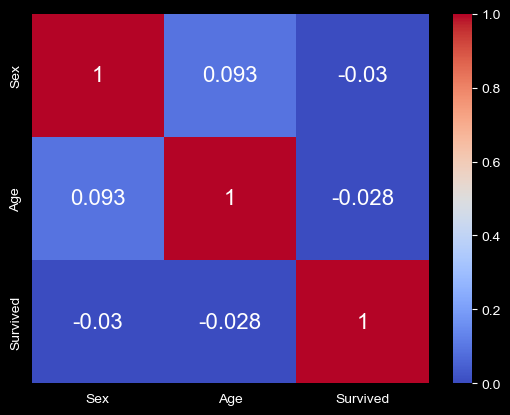

In [503]:
sns.heatmap(corr_data.corr(), annot=True, cmap="coolwarm",
            vmin=0, vmax=1, annot_kws={"size": 16})